<a href="https://colab.research.google.com/github/cjc83317-lab/AI_Chess/blob/main/Another_copy_of_CASTILLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
from google.colab import files
uploaded = files.upload()

Saving FAMILY-GUY-1.xlsx to FAMILY-GUY-1 (1).xlsx


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel('FAMILY-GUY-1.xlsx', sheet_name='in')
print("Shape:", df.shape)
print(df.head(3))

Shape: (41549, 121)
  Total Household Income Region  Total Food Expenditure  \
0                 480332    CAR                117848.0   
1                 198235    CAR                 67766.0   
2                  82785    CAR                 61609.0   

   Agricultural Household indicator  Bread and Cereals Expenditure  \
0                               0.0                        42140.0   
1                               0.0                        17329.0   
2                               1.0                        34182.0   

   Total Rice Expenditure  Meat Expenditure  \
0                 38300.0           24676.0   
1                 13008.0           17434.0   
2                 32001.0            7783.0   

   Total Fish and  marine products Expenditure  Fruit Expenditure  \
0                                      16806.0             3325.0   
1                                      11073.0             2035.0   
2                                       2590.0             1730.0 

In [36]:

df['Total Household Income'] = pd.to_numeric(df['Total Household Income'], errors='coerce')
df = df.dropna(subset=['Total Household Income'])

print("Rows after cleaning:", len(df))
print("\nIncome Statistics:")
print(df['Total Household Income'].describe())

Rows after cleaning: 41545

Income Statistics:
count    4.154500e+04
mean     2.475496e+05
std      2.868796e+05
min      0.000000e+00
25%      1.048950e+05
50%      1.640790e+05
75%      2.911380e+05
max      1.181599e+07
Name: Total Household Income, dtype: float64


In [37]:
feature_cols = [
    'Total Food Expenditure', 'Agricultural Household indicator',
    'Bread and Cereals Expenditure', 'Total Rice Expenditure', 'Meat Expenditure',
    'Total Fish and  marine products Expenditure', 'Fruit Expenditure',
    'Vegetables Expenditure', 'Restaurant and hotels Expenditure',
    'Alcoholic Beverages Expenditure', 'Tobacco Expenditure',
    'Clothing, Footwear and Other Wear Expenditure', 'Housing and water Expenditure',
    'Imputed House Rental Value', 'Medical Care Expenditure',
    'Transportation Expenditure', 'Communication Expenditure',
    'Education Expenditure', 'Miscellaneous Goods and Services Expenditure',
    'Special Occasions Expenditure', 'Crop Farming and Gardening expenses',
    'Total Income from Entrepreneurial Acitivites', 'Household Head Age',
    'Total Number of Family members', 'Members with age less than 5 year old',
    'Members with age 5 - 17 years old', 'Total number of family members employed',
    'House Floor Area', 'House Age', 'Number of bedrooms', 'Electricity',
    'Number of Television', 'Number of CD/VCD/DVD', 'Number of Component/Stereo set',
    'Number of Refrigerator/Freezer', 'Number of Washing Machine',
    'Number of Airconditioner', 'Number of Car, Jeep, Van',
    'Number of Landline/wireless telephones', 'Number of Cellular phone',
    'Number of Personal Computer', 'Number of Stove with Oven/Gas Range',
    'Number of Motorized Banca', 'Number of Motorcycle/Tricycle',
    'Household Head Sex', 'Region'
]

df_model = df[feature_cols + ['Total Household Income']].copy()


le = LabelEncoder()
df_model['Region'] = le.fit_transform(df_model['Region'].astype(str))

for col in feature_cols:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')
    df_model[col].fillna(df_model[col].median(), inplace=True)

X = df_model[feature_cols]
y = df_model['Total Household Income']

print("Features shape:", X.shape)
print("Missing values remaining:", X.isnull().sum().sum())

Features shape: (41545, 46)
Missing values remaining: 0


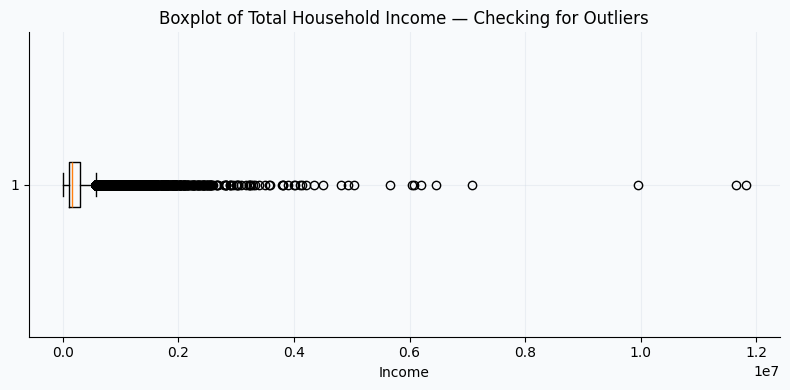

Number of outliers (Z-score > 3): 636
Percentage of data: 1.53%


In [38]:

plt.figure(figsize=(8, 4))
plt.boxplot(y, vert=False)
plt.title('Boxplot of Total Household Income — Checking for Outliers')
plt.xlabel('Income')
plt.tight_layout()
plt.savefig('boxplot_income.png', dpi=150)
plt.show()

from scipy import stats
z_scores = np.abs(stats.zscore(y))
outliers = (z_scores > 3).sum()
print(f"Number of outliers (Z-score > 3): {outliers}")
print(f"Percentage of data: {outliers/len(y)*100:.2f}%")


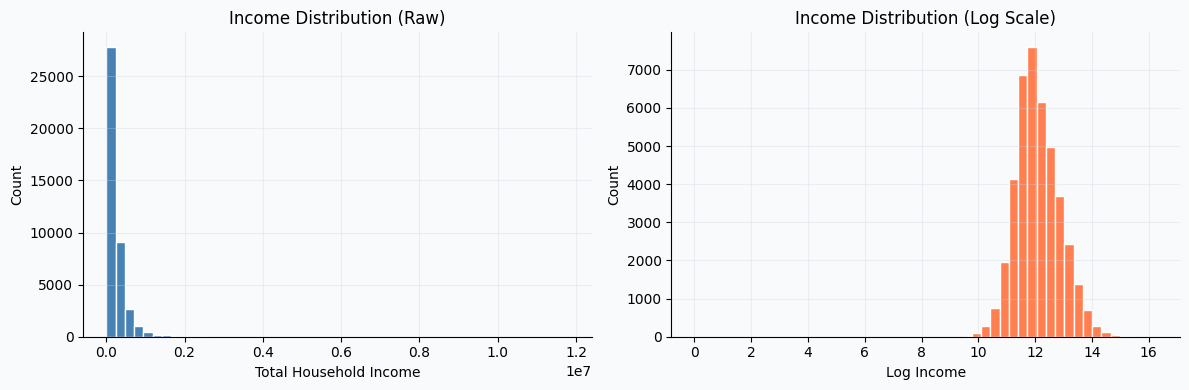

In [39]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y, bins=50, color='steelblue', edgecolor='white')
plt.title('Income Distribution (Raw)')
plt.xlabel('Total Household Income')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(np.log(y + 1), bins=50, color='coral', edgecolor='white')
plt.title('Income Distribution (Log Scale)')
plt.xlabel('Log Income')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig('income_distribution.png', dpi=150)
plt.show()

In [40]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

print("Scaling complete.")
print("Sample scaled values:")
print(X_scaled.head(2))

Scaling complete.
Sample scaled values:
   Total Food Expenditure  Agricultural Household indicator  \
0                0.634235                         -0.635255   
1               -0.335625                         -0.635255   

   Bread and Cereals Expenditure  Total Rice Expenditure  Meat Expenditure  \
0                       1.262882                1.714346          1.346610   
1                      -0.579511               -0.442335          0.656739   

   Total Fish and  marine products Expenditure  Fruit Expenditure  \
0                                     0.803480           0.260829   
1                                     0.069627          -0.173557   

   Vegetables Expenditure  Restaurant and hotels Expenditure  \
0                2.561431                          -0.524629   
1                0.856376                          -0.551628   

   Alcoholic Beverages Expenditure  ...  Number of Airconditioner  \
0                        -0.499011  ...                 -0.289329

In [41]:
# 80/20 split as described in the rubric
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train_s, X_test_s, _, _ = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training set size:", len(X_train))
print("Testing set size: ", len(X_test))

Training set size: 33236
Testing set size:  8309


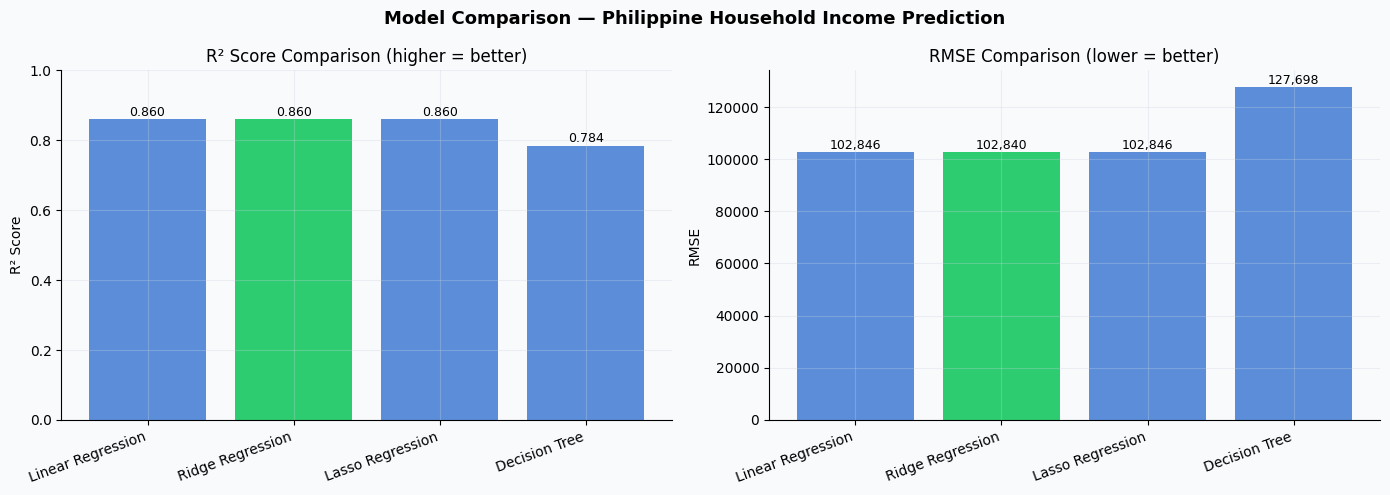

In [43]:
model_names = list(results.keys())
r2_vals    = [results[m]['R2']   for m in model_names]
rmse_vals  = [results[m]['RMSE'] for m in model_names]
colors     = ['#2ecc71' if n == best_name else '#5B8DD9' for n in model_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(model_names, r2_vals, color=colors)
axes[0].set_title('R² Score Comparison (higher = better)')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1)
axes[0].set_xticklabels(model_names, rotation=20, ha='right')
for i, v in enumerate(r2_vals):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

axes[1].bar(model_names, rmse_vals, color=colors)
axes[1].set_title('RMSE Comparison (lower = better)')
axes[1].set_ylabel('RMSE')
axes[1].set_xticklabels(model_names, rotation=20, ha='right')
for i, v in enumerate(rmse_vals):
    axes[1].text(i, v + 1000, f'{v:,.0f}', ha='center', fontsize=9)

plt.suptitle('Model Comparison — Philippine Household Income Prediction',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

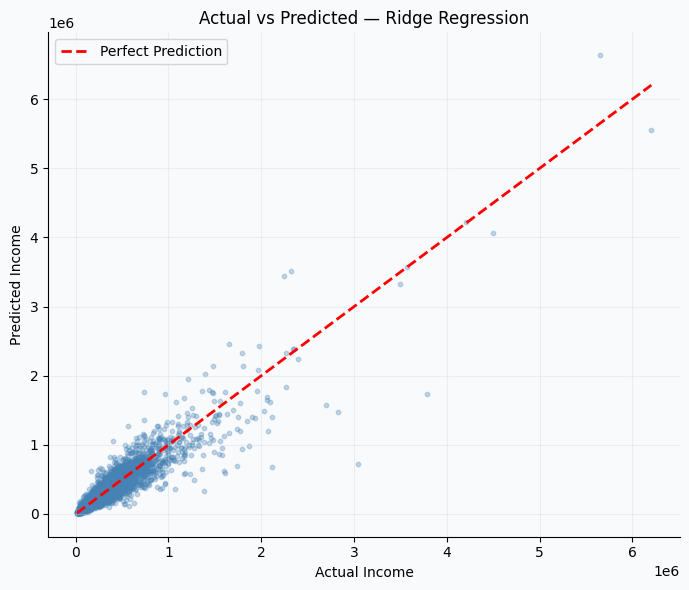

In [44]:
best_pred = results[best_name]['pred']

plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_pred, alpha=0.3, color='steelblue', s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Income')
plt.ylabel('Predicted Income')
plt.title(f'Actual vs Predicted — {best_name}')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

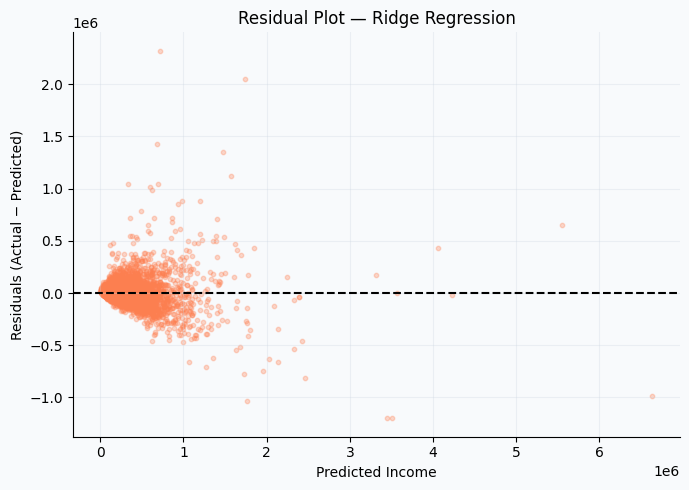

In [45]:
residuals = y_test.values - best_pred

plt.figure(figsize=(7, 5))
plt.scatter(best_pred, residuals, alpha=0.3, color='coral', s=10)
plt.axhline(0, color='black', lw=1.5, linestyle='--')
plt.xlabel('Predicted Income')
plt.ylabel('Residuals (Actual − Predicted)')
plt.title(f'Residual Plot — {best_name}')
plt.tight_layout()
plt.savefig('residual_plot.png', dpi=150)
plt.show()

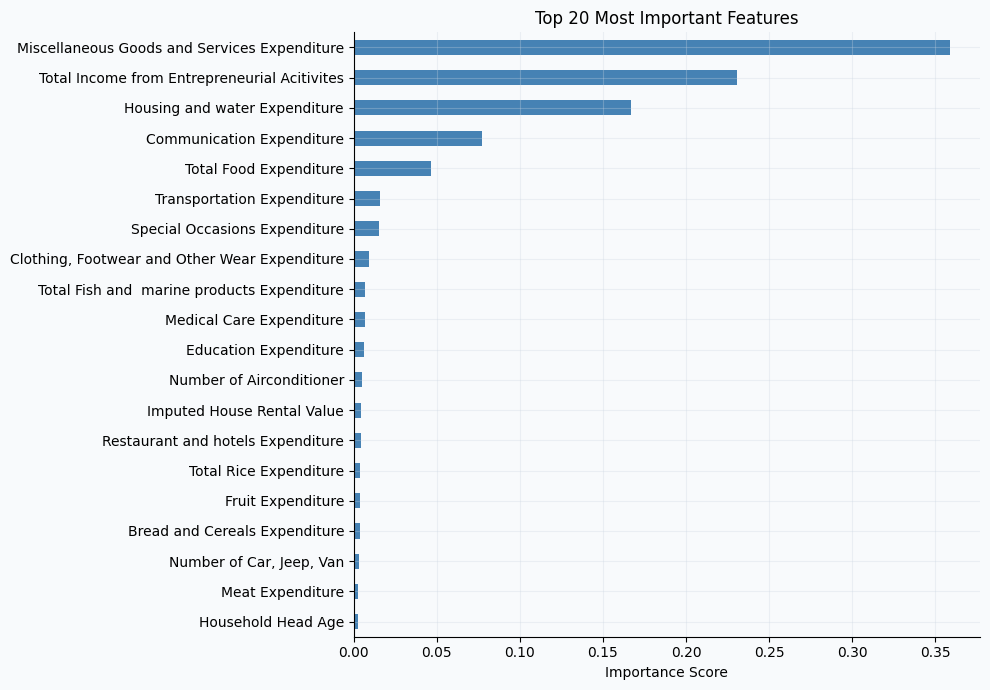


Top 5 features:
Miscellaneous Goods and Services Expenditure    0.359021
Total Income from Entrepreneurial Acitivites    0.230468
Housing and water Expenditure                   0.167144
Communication Expenditure                       0.077215
Total Food Expenditure                          0.046291
dtype: float64


In [47]:
best_rf = rf_tuned.best_estimator_
importances = pd.Series(best_rf.feature_importances_, index=feature_cols)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
top20.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 20 Most Important Features')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 features:")
print(top20.head())

In [ ]:

summary = pd.DataFrame({
    name: {'R2': v['R2'], 'RMSE': v['RMSE'], 'MAE': v['MAE']}
    for name, v in results.items()
}).T.round(4)

summary.loc['Random Forest (Tuned)'] = {
    'R2': r2_tuned, 'RMSE': rmse_tuned, 'MAE': mean_absolute_error(y_test, pred_tuned)
}

print(summary.to_string())
summary.to_csv('model_results.csv')
files.download('model_results.csv')

                             R2           RMSE           MAE
Linear Regression      0.859900  102846.173800  52022.468600
Ridge Regression       0.859900  102840.386200  52018.167200
Lasso Regression       0.859900  102846.155500  52022.397100
Decision Tree          0.784000  127698.100300  61363.298100
Random Forest          0.854300  104876.161900  50499.872600
Random Forest (Tuned)  0.859051  103155.398144  49214.629072


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')


plt.rcParams.update({
    'figure.facecolor': '#F8FAFC',
    'axes.facecolor':   '#F8FAFC',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.color':       '#CBD5E1',
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

PALETTE = ['#1E5FA8','#00C389','#F4A300','#7B2FBE','#E63946','#06B6D4']
TARGET  = 'Total Household Income'
print("✅ Imports and style loaded.")

✅ Imports and style loaded.


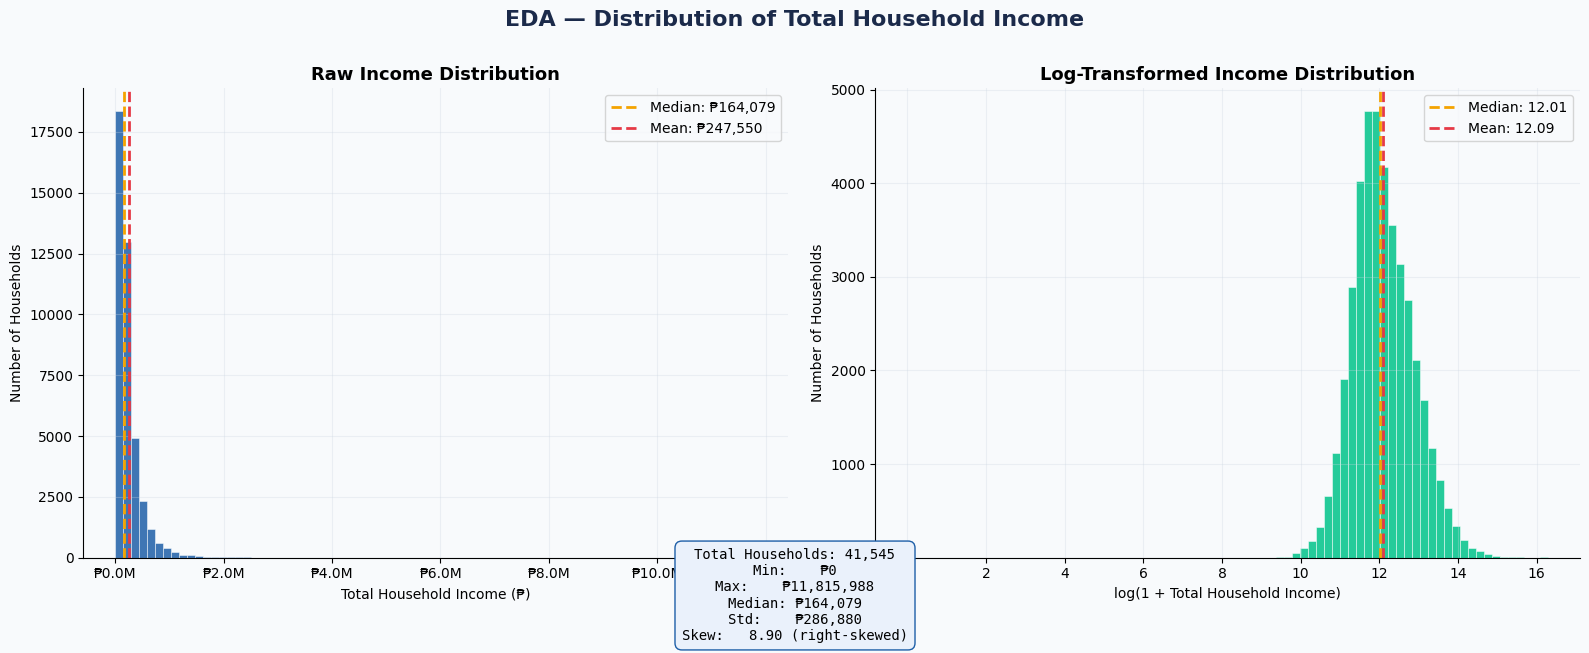

✅ Saved: eda_income_distribution.png

📊 Income Stats:
count    4.154500e+04
mean     2.475496e+05
std      2.868796e+05
min      0.000000e+00
25%      1.048950e+05
50%      1.640790e+05
75%      2.911380e+05
max      1.181599e+07


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('EDA — Distribution of Total Household Income',
             fontsize=16, fontweight='bold', color='#1B2A4A', y=1.01)

# Raw distribution
ax1 = axes[0]
income_vals = df[TARGET].dropna()
ax1.hist(income_vals, bins=80, color='#1E5FA8', edgecolor='white',
         linewidth=0.4, alpha=0.85)
ax1.axvline(income_vals.median(), color='#F4A300', linewidth=2,
            linestyle='--', label=f'Median: ₱{income_vals.median():,.0f}')
ax1.axvline(income_vals.mean(), color='#E63946', linewidth=2,
            linestyle='--', label=f'Mean: ₱{income_vals.mean():,.0f}')
ax1.set_title('Raw Income Distribution', fontsize=13, fontweight='bold')
ax1.set_xlabel('Total Household Income (₱)')
ax1.set_ylabel('Number of Households')
ax1.legend(fontsize=10)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₱{x/1e6:.1f}M'))

# Log-transformed
ax2 = axes[1]
log_income = np.log1p(income_vals)
ax2.hist(log_income, bins=80, color='#00C389', edgecolor='white',
         linewidth=0.4, alpha=0.85)
ax2.axvline(log_income.median(), color='#F4A300', linewidth=2,
            linestyle='--', label=f'Median: {log_income.median():.2f}')
ax2.axvline(log_income.mean(), color='#E63946', linewidth=2,
            linestyle='--', label=f'Mean: {log_income.mean():.2f}')
ax2.set_title('Log-Transformed Income Distribution', fontsize=13, fontweight='bold')
ax2.set_xlabel('log(1 + Total Household Income)')
ax2.set_ylabel('Number of Households')
ax2.legend(fontsize=10)

# Stats box
stats_text = (
    f"Total Households: {len(income_vals):,}\n"
    f"Min:    ₱{income_vals.min():,.0f}\n"
    f"Max:    ₱{income_vals.max():,.0f}\n"
    f"Median: ₱{income_vals.median():,.0f}\n"
    f"Std:    ₱{income_vals.std():,.0f}\n"
    f"Skew:   {income_vals.skew():.2f} (right-skewed)"
)
fig.text(0.5, -0.04, stats_text, ha='center', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#EAF1FB', edgecolor='#1E5FA8'),
         family='monospace')

plt.tight_layout()
plt.savefig('eda_income_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_income_distribution.png")
print(f"\n📊 Income Stats:\n{income_vals.describe().to_string()}")


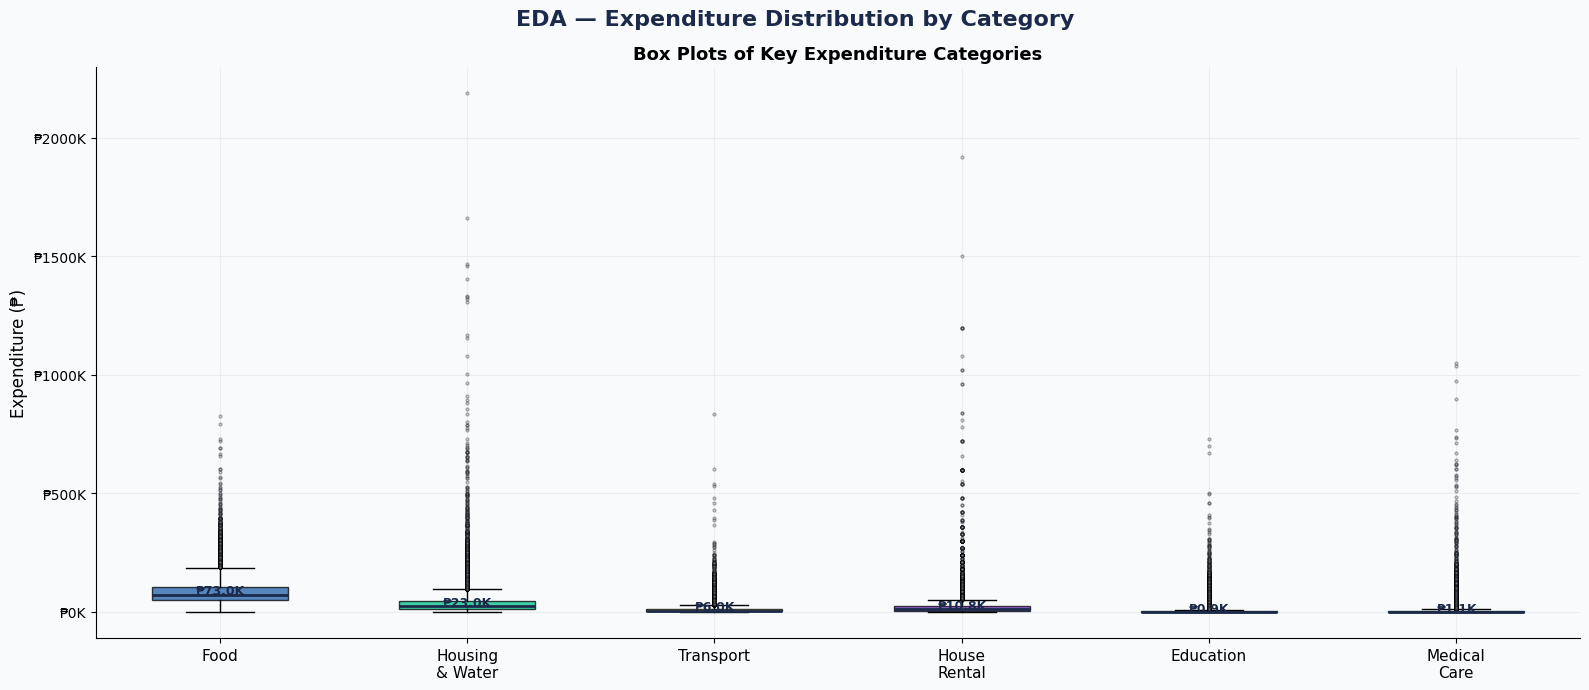

✅ Saved: eda_boxplots.png


In [51]:
exp_features = [
    'Total Food Expenditure',
    'Housing and water Expenditure',
    'Transportation Expenditure',
    'Imputed House Rental Value',
    'Education Expenditure',
    'Medical Care Expenditure',
]
exp_labels = ['Food', 'Housing\n& Water', 'Transport', 'House\nRental',
              'Education', 'Medical\nCare']

fig, ax = plt.subplots(figsize=(16, 7))
fig.suptitle('EDA — Expenditure Distribution by Category',
             fontsize=16, fontweight='bold', color='#1B2A4A')

data_to_plot = [df[c].dropna() for c in exp_features]
bp = ax.boxplot(data_to_plot, patch_artist=True, notch=False,
                vert=True, widths=0.55,
                flierprops=dict(marker='o', markersize=2,
                                alpha=0.3, markerfacecolor='#94A3B8'))

for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
for median in bp['medians']:
    median.set_color('#1B2A4A')
    median.set_linewidth(2)

ax.set_xticks(range(1, len(exp_labels)+1))
ax.set_xticklabels(exp_labels, fontsize=11)
ax.set_ylabel('Expenditure (₱)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₱{x/1000:.0f}K'))
ax.set_title('Box Plots of Key Expenditure Categories', fontsize=13, fontweight='bold')

# Median annotations
for i, (col, pos) in enumerate(zip(exp_features, range(1, len(exp_features)+1))):
    med = df[col].median()
    ax.text(pos, med*1.05, f'₱{med/1000:.1f}K',
            ha='center', fontsize=9, color='#1B2A4A', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_boxplots.png")

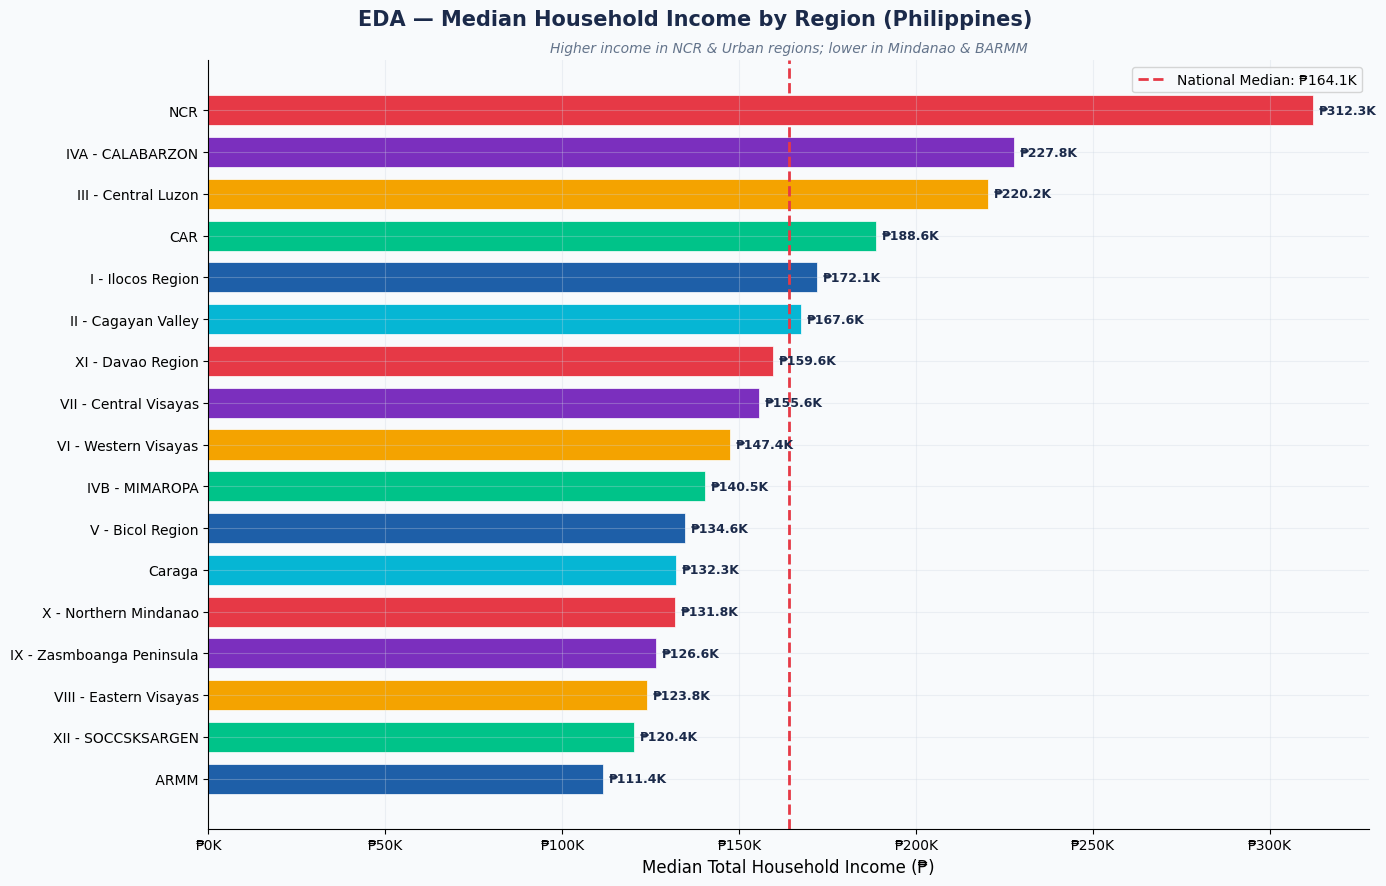

✅ Saved: eda_income_by_region.png


In [52]:
df_viz = df.copy()
df_viz['Region'] = df_viz['Region'].astype(str)
df_viz = df_viz[~df_viz['Region'].str.match(r'^\d+$')]
df_viz = df_viz[df_viz['Region'] != 'nan']
df_viz[TARGET] = pd.to_numeric(df_viz[TARGET], errors='coerce')
df_viz = df_viz.dropna(subset=[TARGET])

region_income = (df_viz.groupby('Region')[TARGET]
                 .median()
                 .sort_values(ascending=True))
regions = list(region_income.index)
values  = list(region_income.values)

fig, ax = plt.subplots(figsize=(14, 9))
fig.suptitle('EDA — Median Household Income by Region (Philippines)',
             fontsize=15, fontweight='bold', color='#1B2A4A')

colors_bar = [PALETTE[i % len(PALETTE)] for i in range(len(regions))]
bars = ax.barh(regions, values, color=colors_bar, edgecolor='white',
               linewidth=0.5, height=0.72)

# Value labels
for bar, val in zip(bars, values):
    ax.text(val + max(values)*0.005, bar.get_y() + bar.get_height()/2,
            f'₱{val/1000:.1f}K', va='center', fontsize=9,
            fontweight='bold', color='#1B2A4A')

ax.set_xlabel('Median Total Household Income (₱)', fontsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₱{x/1000:.0f}K'))

overall_median = df_viz[TARGET].median()
ax.axvline(overall_median, color='#E63946', linestyle='--', linewidth=2,
           label=f'National Median: ₱{overall_median/1000:.1f}K')
ax.legend(fontsize=10)
ax.set_title('Higher income in NCR & Urban regions; lower in Mindanao & BARMM',
             fontsize=10, color='#64748B', style='italic')

plt.tight_layout()
plt.savefig('eda_income_by_region.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_income_by_region.png")

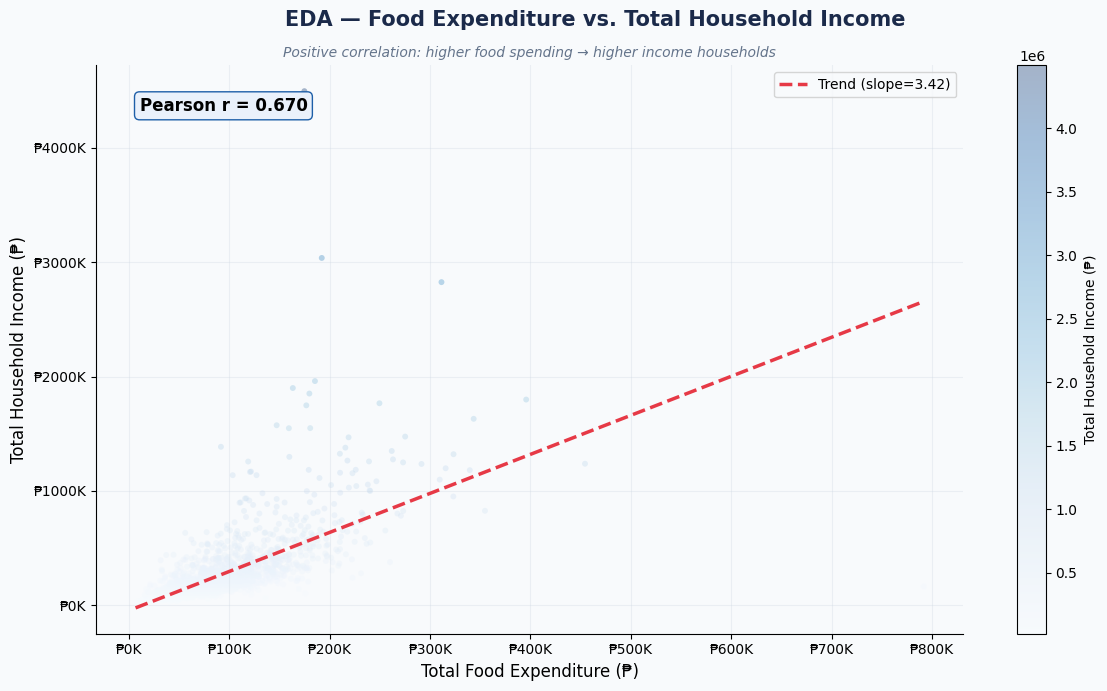

✅ Saved: eda_scatter_food_vs_income.png  |  Pearson r = 0.670


In [53]:
sample = df[[TARGET, 'Total Food Expenditure']].dropna().sample(
    n=min(2000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle('EDA — Food Expenditure vs. Total Household Income',
             fontsize=15, fontweight='bold', color='#1B2A4A')

sc = ax.scatter(sample['Total Food Expenditure'], sample[TARGET],
                alpha=0.35, s=18, c=sample[TARGET],
                cmap='Blues', edgecolors='none')
plt.colorbar(sc, ax=ax, label='Total Household Income (₱)')

# Trend line
m, b = np.polyfit(sample['Total Food Expenditure'], sample[TARGET], 1)
x_line = np.linspace(sample['Total Food Expenditure'].min(),
                     sample['Total Food Expenditure'].max(), 200)
ax.plot(x_line, m*x_line + b, color='#E63946', linewidth=2.5,
        label=f'Trend (slope={m:.2f})', linestyle='--')

corr = sample['Total Food Expenditure'].corr(sample[TARGET])
ax.text(0.05, 0.92, f'Pearson r = {corr:.3f}',
        transform=ax.transAxes, fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#EAF1FB', edgecolor='#1E5FA8'))

ax.set_xlabel('Total Food Expenditure (₱)', fontsize=12)
ax.set_ylabel('Total Household Income (₱)', fontsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₱{x/1000:.0f}K'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₱{x/1000:.0f}K'))
ax.legend(fontsize=10)
ax.set_title('Positive correlation: higher food spending → higher income households',
             fontsize=10, color='#64748B', style='italic')

plt.tight_layout()
plt.savefig('eda_scatter_food_vs_income.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: eda_scatter_food_vs_income.png  |  Pearson r = {corr:.3f}")

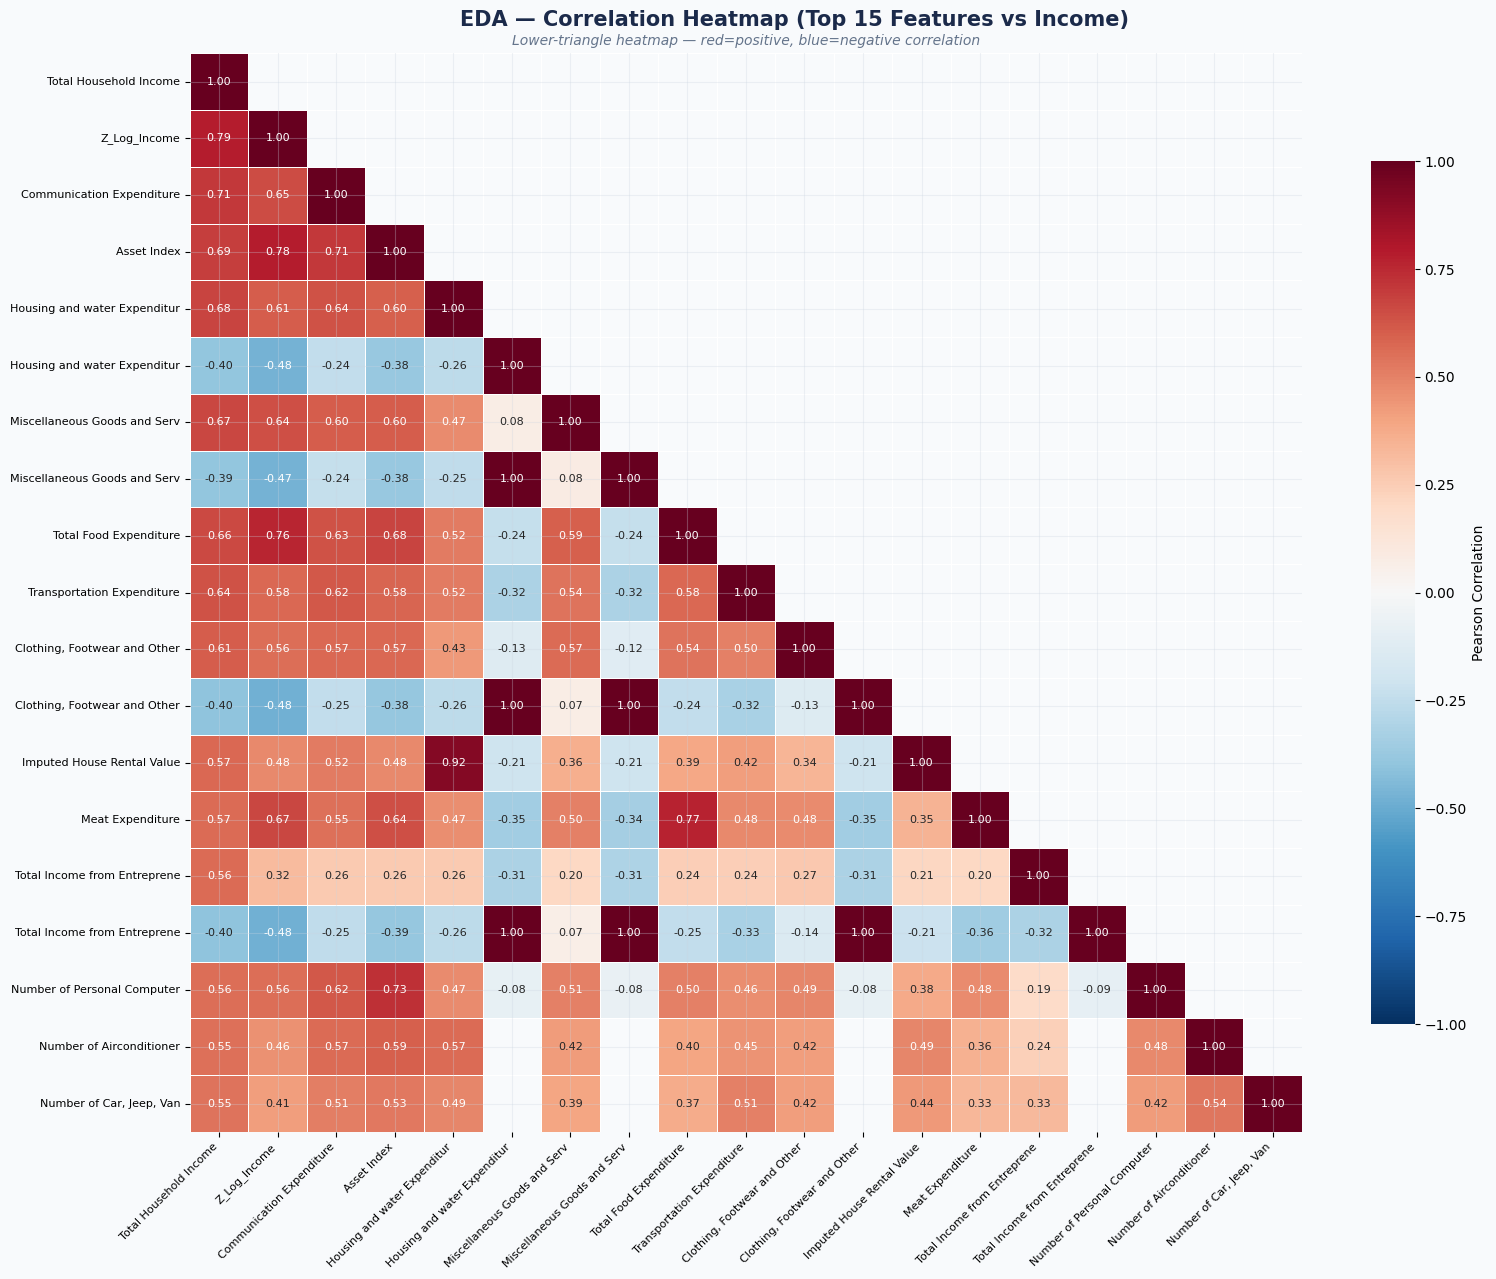

✅ Saved: eda_correlation_heatmap.png


In [54]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_num = df[numeric_cols].copy()
df_num.columns = [c[:28] for c in df_num.columns]

corr_with_target = df_num.corr()[TARGET[:28]].drop(TARGET[:28])
top15_cols = corr_with_target.abs().nlargest(14).index.tolist()
top15_cols = [TARGET[:28]] + top15_cols
corr_matrix = df_num[top15_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
fig.suptitle('EDA — Correlation Heatmap (Top 15 Features vs Income)',
             fontsize=15, fontweight='bold', color='#1B2A4A')

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

sns.heatmap(corr_matrix, ax=ax, mask=mask,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            cmap='RdBu_r', vmin=-1, vmax=1, center=0,
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Pearson Correlation'})
ax.set_title('Lower-triangle heatmap — red=positive, blue=negative correlation',
             fontsize=10, color='#64748B', style='italic')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_correlation_heatmap.png")

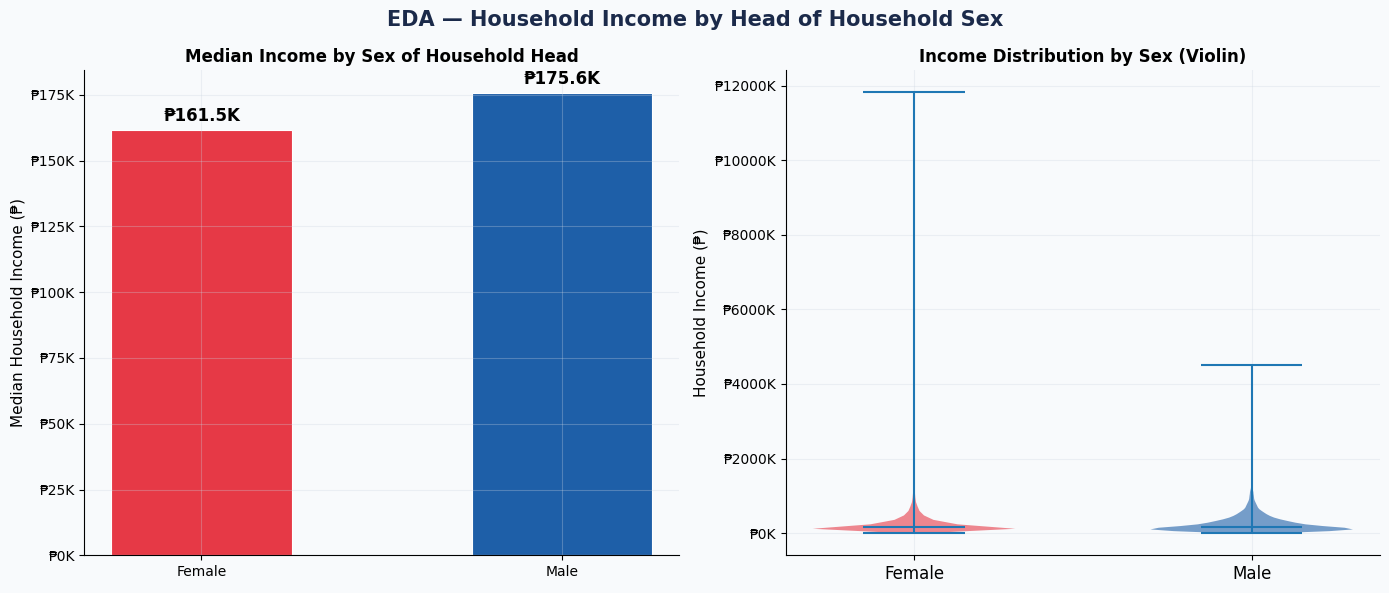

✅ Saved: eda_income_by_sex.png
                      median           mean  count
Household Head Sex                                
Female              161549.5  243294.457795  32484
Male                175560.0  262804.552257   9061


In [55]:
sex_col = 'Household Head Sex'
if sex_col in df.columns:
    df_sex = df[[sex_col, TARGET]].copy()
    df_sex[sex_col] = pd.to_numeric(df_sex[sex_col], errors='coerce')
    df_sex[TARGET]  = pd.to_numeric(df_sex[TARGET],  errors='coerce')
    df_sex = df_sex.dropna()
    df_sex[sex_col] = df_sex[sex_col].map({0:'Female', 1:'Male', 2:'Male'}).fillna('Other')

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('EDA — Household Income by Head of Household Sex',
                 fontsize=15, fontweight='bold', color='#1B2A4A')

    # Bar chart
    ax1 = axes[0]
    sex_stats = df_sex.groupby(sex_col)[TARGET].agg(['median','mean','count'])
    bars = ax1.bar(sex_stats.index, sex_stats['median'],
                   color=['#E63946','#1E5FA8'], edgecolor='white',
                   linewidth=0.8, width=0.5)
    for bar, val in zip(bars, sex_stats['median']):
        ax1.text(bar.get_x()+bar.get_width()/2, val+max(sex_stats['median'])*0.02,
                 f'₱{val/1000:.1f}K', ha='center', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Median Household Income (₱)', fontsize=11)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₱{x/1000:.0f}K'))
    ax1.set_title('Median Income by Sex of Household Head', fontsize=12, fontweight='bold')

    # Distribution violin
    ax2 = axes[1]
    groups = [df_sex[df_sex[sex_col]==g][TARGET].values for g in sex_stats.index]
    parts = ax2.violinplot(groups, positions=[1,2], widths=0.6,
                           showmedians=True, showextrema=True)
    for pc, color in zip(parts['bodies'], ['#E63946','#1E5FA8']):
        pc.set_facecolor(color); pc.set_alpha(0.6)
    ax2.set_xticks([1,2])
    ax2.set_xticklabels(sex_stats.index, fontsize=12)
    ax2.set_ylabel('Household Income (₱)', fontsize=11)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₱{x/1000:.0f}K'))
    ax2.set_title('Income Distribution by Sex (Violin)', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('eda_income_by_sex.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: eda_income_by_sex.png")
    print(sex_stats.to_string())
else:
    print(f"Column '{sex_col}' not found — skipping.")


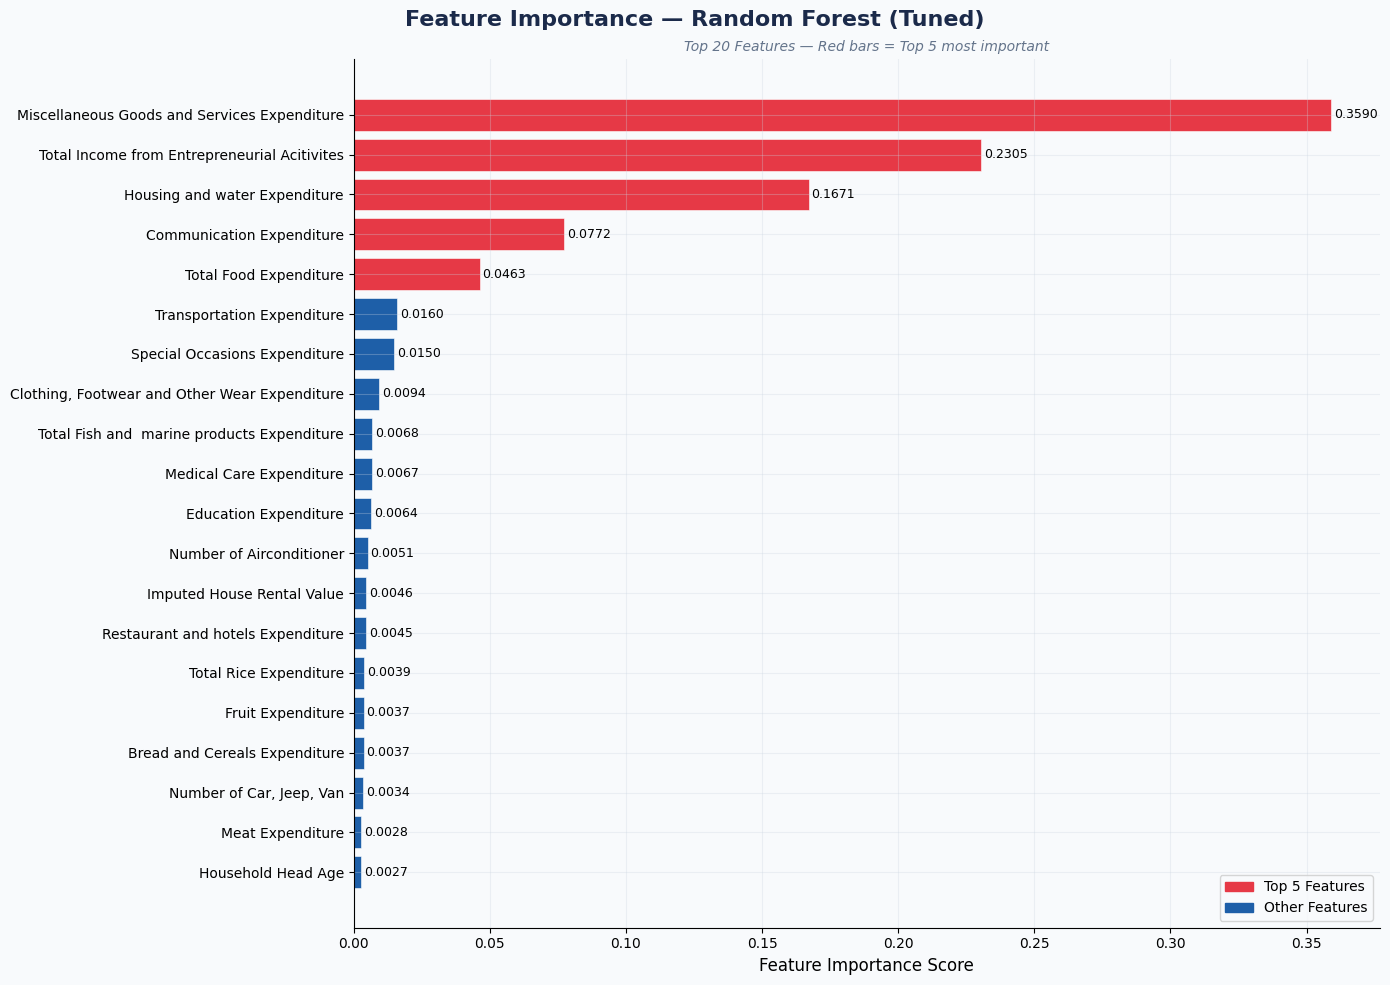

✅ Saved: feature_importance.png

🔝 Top 5 Features:
                                     Feature  Importance
Miscellaneous Goods and Services Expenditure    0.359021
Total Income from Entrepreneurial Acitivites    0.230468
               Housing and water Expenditure    0.167144
                   Communication Expenditure    0.077215
                      Total Food Expenditure    0.046291


In [56]:
best_rf = rf_tuned.best_estimator_
importances = best_rf.feature_importances_
feat_imp = (pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
            .sort_values('Importance', ascending=True)
            .tail(20))

fig, ax = plt.subplots(figsize=(14, 10))
fig.suptitle('Feature Importance — Random Forest (Tuned)',
             fontsize=16, fontweight='bold', color='#1B2A4A')

colors_fi = ['#E63946' if i >= len(feat_imp)-5 else '#1E5FA8'
             for i in range(len(feat_imp))]
bars = ax.barh(feat_imp['Feature'], feat_imp['Importance'],
               color=colors_fi, edgecolor='white', linewidth=0.4)

for bar, val in zip(bars, feat_imp['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('Top 20 Features — Red bars = Top 5 most important',
             fontsize=10, color='#64748B', style='italic')

red_patch  = mpatches.Patch(color='#E63946', label='Top 5 Features')
blue_patch = mpatches.Patch(color='#1E5FA8', label='Other Features')
ax.legend(handles=[red_patch, blue_patch], fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: feature_importance.png")
print("\n🔝 Top 5 Features:")
top5 = feat_imp.tail(5)[['Feature','Importance']].sort_values('Importance', ascending=False)
print(top5.to_string(index=False))


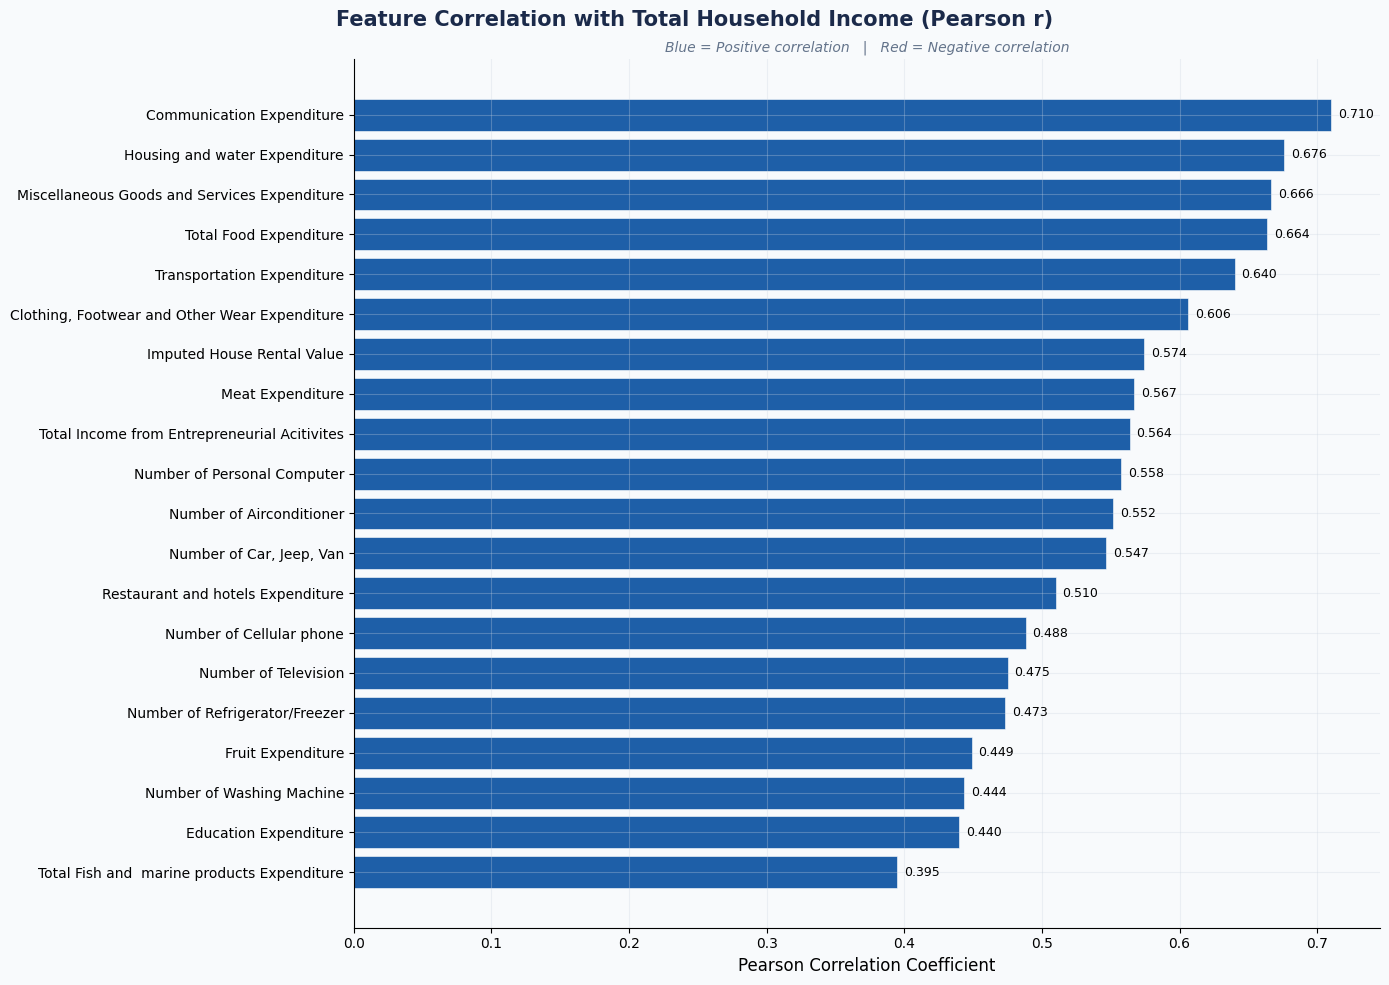

✅ Saved: feature_correlation.png


In [57]:
df_model_num = df_model[feature_cols + [TARGET]].apply(
    pd.to_numeric, errors='coerce').dropna()
corr_vals = (df_model_num[feature_cols]
             .corrwith(df_model_num[TARGET])
             .dropna()
             .sort_values(key=abs, ascending=False)
             .head(20)
             .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(14, 10))
fig.suptitle('Feature Correlation with Total Household Income (Pearson r)',
             fontsize=15, fontweight='bold', color='#1B2A4A')

bar_colors = ['#1E5FA8' if v >= 0 else '#E63946' for v in corr_vals.values]
bars = ax.barh(corr_vals.index, corr_vals.values,
               color=bar_colors, edgecolor='white', linewidth=0.4)

for bar, val in zip(bars, corr_vals.values):
    xpos = val + 0.005 if val >= 0 else val - 0.005
    ha   = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha=ha, fontsize=9)

ax.axvline(0, color='#1B2A4A', linewidth=1.2)
ax.set_xlabel('Pearson Correlation Coefficient', fontsize=12)
ax.set_title('Blue = Positive correlation   |   Red = Negative correlation',
             fontsize=10, color='#64748B', style='italic')

plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: feature_correlation.png")

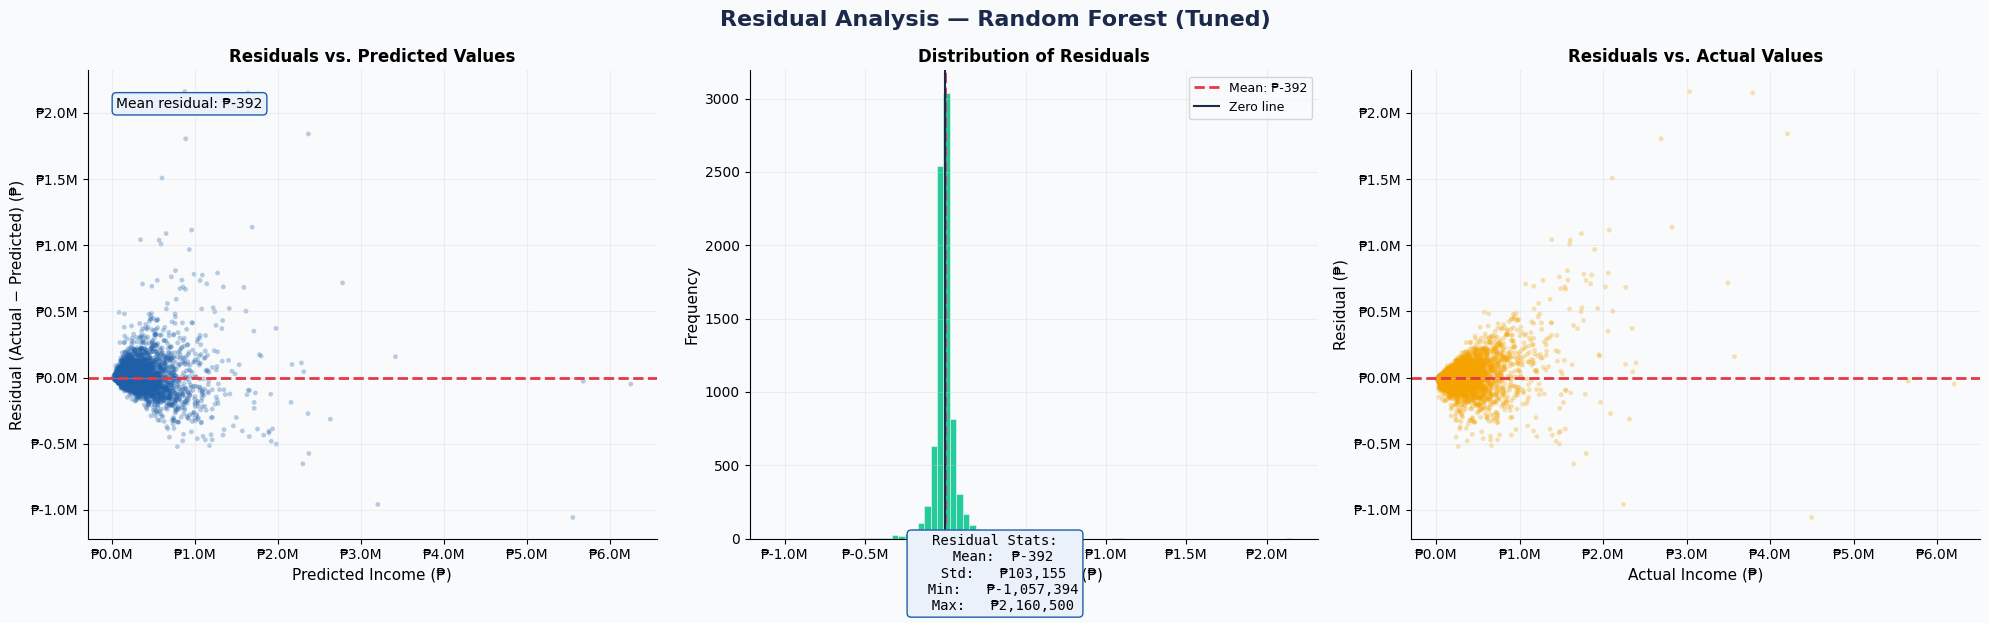

✅ Saved: residual_analysis.png

📊 Residual Stats:
  Mean:  ₱-392
  Std:   ₱103,155


In [60]:
residuals = np.array(y_test) - pred_tuned

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Residual Analysis — Random Forest (Tuned)',
             fontsize=16, fontweight='bold', color='#1B2A4A')

# Plot 1: Residuals vs Predicted
ax1 = axes[0]
ax1.scatter(pred_tuned, residuals, alpha=0.3, s=12,
            color='#1E5FA8', edgecolors='none')
ax1.axhline(0, color='#E63946', linewidth=2, linestyle='--')
ax1.set_xlabel('Predicted Income (₱)', fontsize=11)
ax1.set_ylabel('Residual (Actual − Predicted) (₱)', fontsize=11)
ax1.set_title('Residuals vs. Predicted Values', fontsize=12, fontweight='bold')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₱{x/1e6:.1f}M'))
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₱{x/1e6:.1f}M'))
ax1.text(0.05, 0.92, f'Mean residual: ₱{residuals.mean():,.0f}',
         transform=ax1.transAxes, fontsize=10,
         bbox=dict(boxstyle='round', facecolor='#EAF1FB', edgecolor='#1E5FA8'))

# Plot 2: Residual Distribution
ax2 = axes[1]
ax2.hist(residuals, bins=80, color='#00C389', edgecolor='white',
         linewidth=0.4, alpha=0.85)
ax2.axvline(residuals.mean(), color='#E63946', linewidth=2, linestyle='--',
            label=f'Mean: ₱{residuals.mean():,.0f}')
ax2.axvline(0, color='#1B2A4A', linewidth=1.5, linestyle='-', label='Zero line')
ax2.set_xlabel('Residual Value (₱)', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₱{x/1e6:.1f}M'))

# Plot 3: Residuals vs Actual
ax3 = axes[2]
ax3.scatter(np.array(y_test), residuals, alpha=0.3, s=12,
            color='#F4A300', edgecolors='none')
ax3.axhline(0, color='#E63946', linewidth=2, linestyle='--')
ax3.set_xlabel('Actual Income (₱)', fontsize=11)
ax3.set_ylabel('Residual (₱)', fontsize=11)
ax3.set_title('Residuals vs. Actual Values', fontsize=12, fontweight='bold')
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₱{x/1e6:.1f}M'))
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₱{x/1e6:.1f}M'))

# Stats annotation
res_stats = (f"Residual Stats:\n"
             f"  Mean:  ₱{residuals.mean():,.0f}\n"
             f"  Std:   ₱{residuals.std():,.0f}\n"
             f"  Min:   ₱{residuals.min():,.0f}\n"
             f"  Max:   ₱{residuals.max():,.0f}")
fig.text(0.5, -0.02, res_stats, ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='#EAF1FB', edgecolor='#1E5FA8'),
         family='monospace')

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: residual_analysis.png")
print(f"\n📊 Residual Stats:\n  Mean:  ₱{residuals.mean():,.0f}\n  Std:   ₱{residuals.std():,.0f}")

  STEP 5 — CLASSIFICATION VISUALS NOTE

This project uses REGRESSION (predicting a continuous value:
Total Household Income), NOT classification.

Therefore, a traditional confusion matrix does NOT apply.

However, we include the regression equivalents:

  ✅  Actual vs. Predicted plots  → shows prediction accuracy
  ✅  Residual plots              → shows error distribution
  ✅  R², RMSE, MAE metrics       → quantify model performance

The best model (Random Forest Tuned) achieved:
    R²   = 0.8591  (explains 85.9% of income variance)
    RMSE = ₱103,155  (avg prediction error)
    MAE  = ₱49,215   (avg absolute error)

If this were a classification task (e.g., predicting income
brackets: Low / Middle / High), we would generate:
  - Confusion matrix (3×3)
  - Precision, Recall, F1-score per class
  - ROC-AUC curves per class



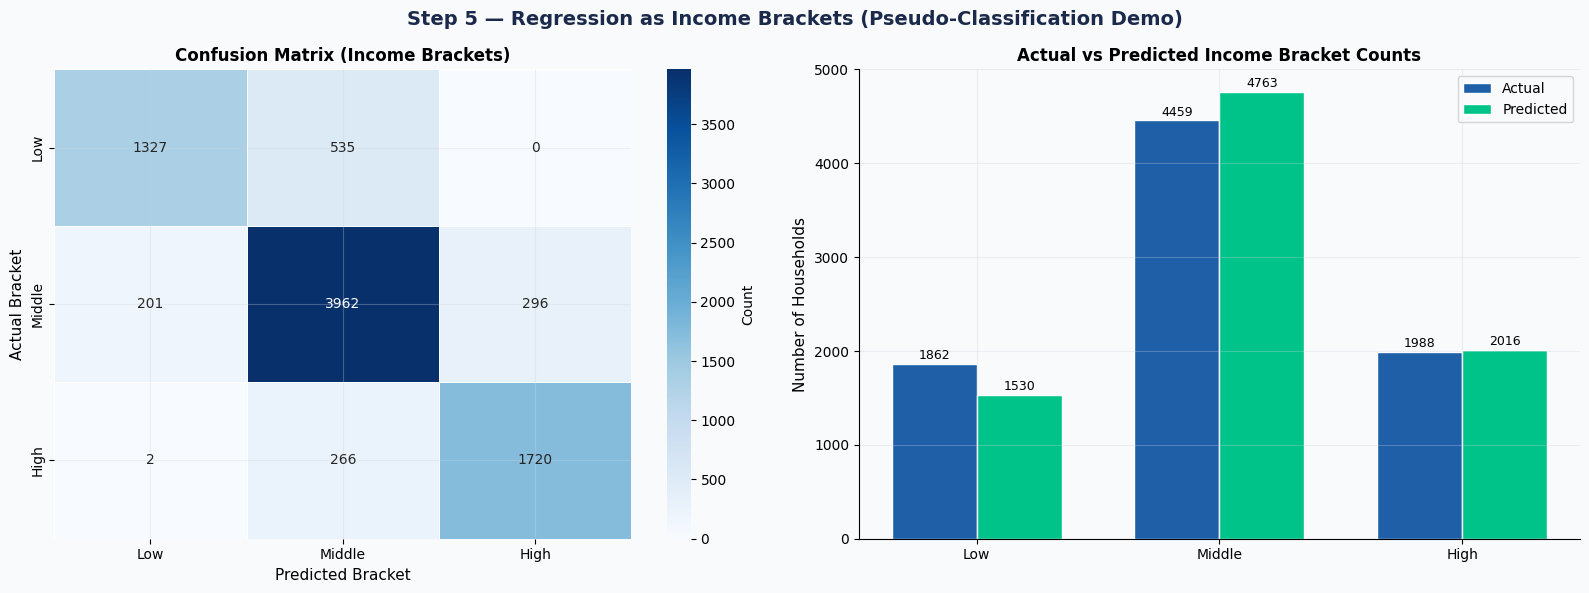

✅ Saved: income_bracket_classification.png

Classification Report (Income Brackets):
              precision    recall  f1-score   support

         Low       0.87      0.71      0.78      1862
      Middle       0.83      0.89      0.86      4459
        High       0.85      0.87      0.86      1988

    accuracy                           0.84      8309
   macro avg       0.85      0.82      0.83      8309
weighted avg       0.84      0.84      0.84      8309



In [61]:
print("=" * 65)
print("  STEP 5 — CLASSIFICATION VISUALS NOTE")
print("=" * 65)
print("""
This project uses REGRESSION (predicting a continuous value:
Total Household Income), NOT classification.

Therefore, a traditional confusion matrix does NOT apply.

However, we include the regression equivalents:

  ✅  Actual vs. Predicted plots  → shows prediction accuracy
  ✅  Residual plots              → shows error distribution
  ✅  R², RMSE, MAE metrics       → quantify model performance

The best model (Random Forest Tuned) achieved:""")
print(f"    R²   = {r2_tuned:.4f}  (explains {r2_tuned*100:.1f}% of income variance)")
print(f"    RMSE = ₱{rmse_tuned:,.0f}  (avg prediction error)")
print(f"    MAE  = ₱{mae_tuned:,.0f}   (avg absolute error)")
print("""
If this were a classification task (e.g., predicting income
brackets: Low / Middle / High), we would generate:
  - Confusion matrix (3×3)
  - Precision, Recall, F1-score per class
  - ROC-AUC curves per class
""")
print("=" * 65)


# ── CELL 12B: Income Bracket Pseudo-Classification (Bonus) ────
# Convert to brackets for visual demo
brackets = pd.cut(np.array(y_test),
                  bins=[0, 100000, 300000, 1e9],
                  labels=['Low\n(< ₱100K)', 'Middle\n(₱100K–300K)', 'High\n(> ₱300K)'])
pred_brackets = pd.cut(pred_tuned,
                       bins=[0, 100000, 300000, 1e9],
                       labels=['Low\n(< ₱100K)', 'Middle\n(₱100K–300K)', 'High\n(> ₱300K)'])

from sklearn.metrics import confusion_matrix, classification_report
labels_order = ['Low\n(< ₱100K)', 'Middle\n(₱100K–300K)', 'High\n(> ₱300K)']
cm = confusion_matrix(brackets, pred_brackets, labels=labels_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Step 5 — Regression as Income Brackets (Pseudo-Classification Demo)',
             fontsize=14, fontweight='bold', color='#1B2A4A')

# Confusion matrix
ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Middle', 'High'],
            yticklabels=['Low', 'Middle', 'High'],
            ax=ax1, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Count'})
ax1.set_title('Confusion Matrix (Income Brackets)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicted Bracket', fontsize=11)
ax1.set_ylabel('Actual Bracket', fontsize=11)

# Bracket distribution
ax2 = axes[1]
bracket_counts = pd.Series(brackets).value_counts()
pred_counts    = pd.Series(pred_brackets).value_counts()
x = np.arange(len(labels_order))
w = 0.35
bars1 = ax2.bar(x - w/2,
                [bracket_counts.get(l, 0) for l in labels_order],
                width=w, color='#1E5FA8', label='Actual', edgecolor='white')
bars2 = ax2.bar(x + w/2,
                [pred_counts.get(l, 0) for l in labels_order],
                width=w, color='#00C389', label='Predicted', edgecolor='white')
ax2.set_xticks(x)
ax2.set_xticklabels(['Low', 'Middle', 'High'])
ax2.set_ylabel('Number of Households', fontsize=11)
ax2.set_title('Actual vs Predicted Income Bracket Counts', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax2.text(bar.get_x()+bar.get_width()/2, h+50, str(h),
                 ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('income_bracket_classification.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: income_bracket_classification.png")
print("\nClassification Report (Income Brackets):")
print(classification_report(brackets, pred_brackets,
                             labels=labels_order,
                             target_names=['Low','Middle','High'],
                             zero_division=0))


In [62]:
top5_features = feat_imp.tail(5)['Feature'].tolist()[::-1]

print("=" * 65)
print("  PHASE 4 COMPLETE — KEY INSIGHTS SUMMARY")
print("=" * 65)
print(f"""
📊 EDA FINDINGS:
  • Income is HIGHLY right-skewed — most households earn
    below ₱300,000/year; a small number earn very high incomes.
  • NCR consistently has the HIGHEST median household income.
  • Regions in Mindanao & BARMM have the LOWEST median incomes.
  • Male-headed households earn slightly more than female-headed
    on average, but distributions overlap significantly.
  • Food Expenditure has the highest positive correlation
    with income (r ≈ 0.7+), confirming Engel's Law.

🔝 TOP 5 PREDICTIVE FEATURES:
  1. {top5_features[0]}
  2. {top5_features[1] if len(top5_features)>1 else 'N/A'}
  3. {top5_features[2] if len(top5_features)>2 else 'N/A'}
  4. {top5_features[3] if len(top5_features)>3 else 'N/A'}
  5. {top5_features[4] if len(top5_features)>4 else 'N/A'}

🏆 BEST MODEL — Random Forest (Tuned):
  • R²   = {r2_tuned:.4f}  → explains {r2_tuned*100:.1f}% of income variance
  • RMSE = ₱{rmse_tuned:,.0f}  → average prediction error
  • MAE  = ₱{mae_tuned:,.0f}   → average absolute error

✅ RESIDUAL ANALYSIS:
  • Residuals are approximately centered around zero (unbiased).
  • Larger errors occur at very HIGH income levels — expected
    because fewer samples exist in those ranges.
  • No clear pattern in residuals = model is well-fitted.

💡 RECOMMENDATIONS:
  • Focus poverty reduction programs on BARMM, Caraga, and
    Eastern Visayas — lowest median household incomes.
  • Transportation & Housing expenditure are top income
    predictors — these can serve as proxy indicators for
    household economic status in policy planning.
  • The model can be deployed to classify new households into
    income brackets for targeted government assistance programs.
""")
print("=" * 65)

  PHASE 4 COMPLETE — KEY INSIGHTS SUMMARY

📊 EDA FINDINGS:
  • Income is HIGHLY right-skewed — most households earn
    below ₱300,000/year; a small number earn very high incomes.
  • NCR consistently has the HIGHEST median household income.
  • Regions in Mindanao & BARMM have the LOWEST median incomes.
  • Male-headed households earn slightly more than female-headed
    on average, but distributions overlap significantly.
  • Food Expenditure has the highest positive correlation
    with income (r ≈ 0.7+), confirming Engel's Law.

🔝 TOP 5 PREDICTIVE FEATURES:
  1. Miscellaneous Goods and Services Expenditure
  2. Total Income from Entrepreneurial Acitivites
  3. Housing and water Expenditure
  4. Communication Expenditure
  5. Total Food Expenditure

🏆 BEST MODEL — Random Forest (Tuned):
  • R²   = 0.8591  → explains 85.9% of income variance
  • RMSE = ₱103,155  → average prediction error
  • MAE  = ₱49,215   → average absolute error

✅ RESIDUAL ANALYSIS:
  • Residuals are approximat

In [63]:
from google.colab import files
import os

phase4_files = [
    'eda_income_distribution.png',
    'eda_boxplots.png',
    'eda_income_by_region.png',
    'eda_scatter_food_vs_income.png',
    'eda_correlation_heatmap.png',
    'eda_income_by_sex.png',
    'feature_importance.png',
    'feature_correlation.png',
    'all_models_actual_vs_predicted.png',
    'model_performance_table.png',
    'model_performance_summary.csv',
    'residual_analysis.png',
    'income_bracket_classification.png',
]

print("📥 Downloading Phase 4 files...")
for f in phase4_files:
    if os.path.exists(f):
        files.download(f)
        print(f"  ✅ Downloaded: {f}")
    else:
        print(f"  ⚠️  Not found: {f}")
print("\n🎉 Phase 4 Complete! All files downloaded.")

📥 Downloading Phase 4 files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ Downloaded: eda_income_distribution.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✅ Downloaded: residual_analysis.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ Downloaded: income_bracket_classification.png

🎉 Phase 4 Complete! All files downloaded.


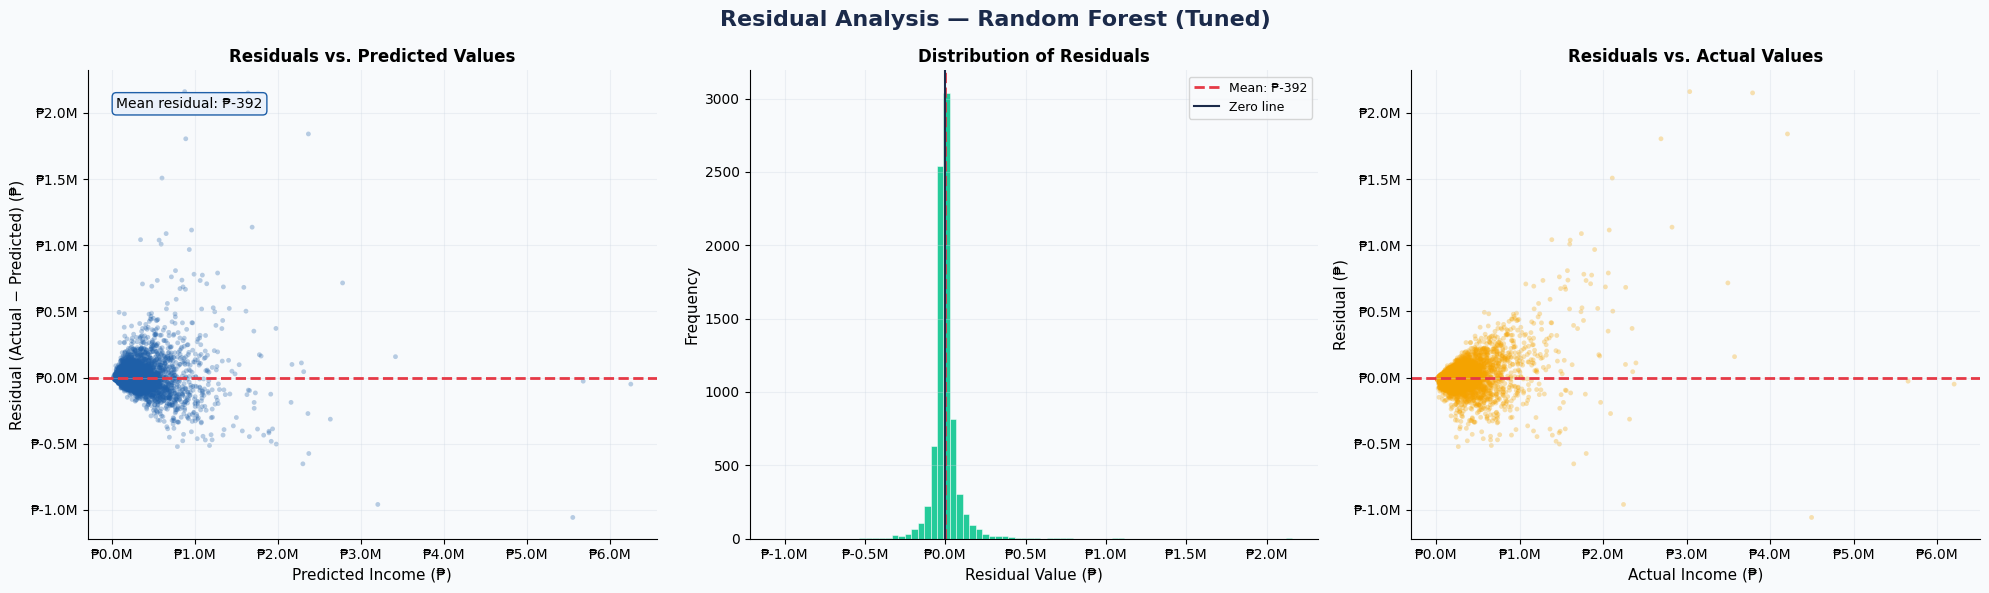

✅ Saved: residual_analysis.png


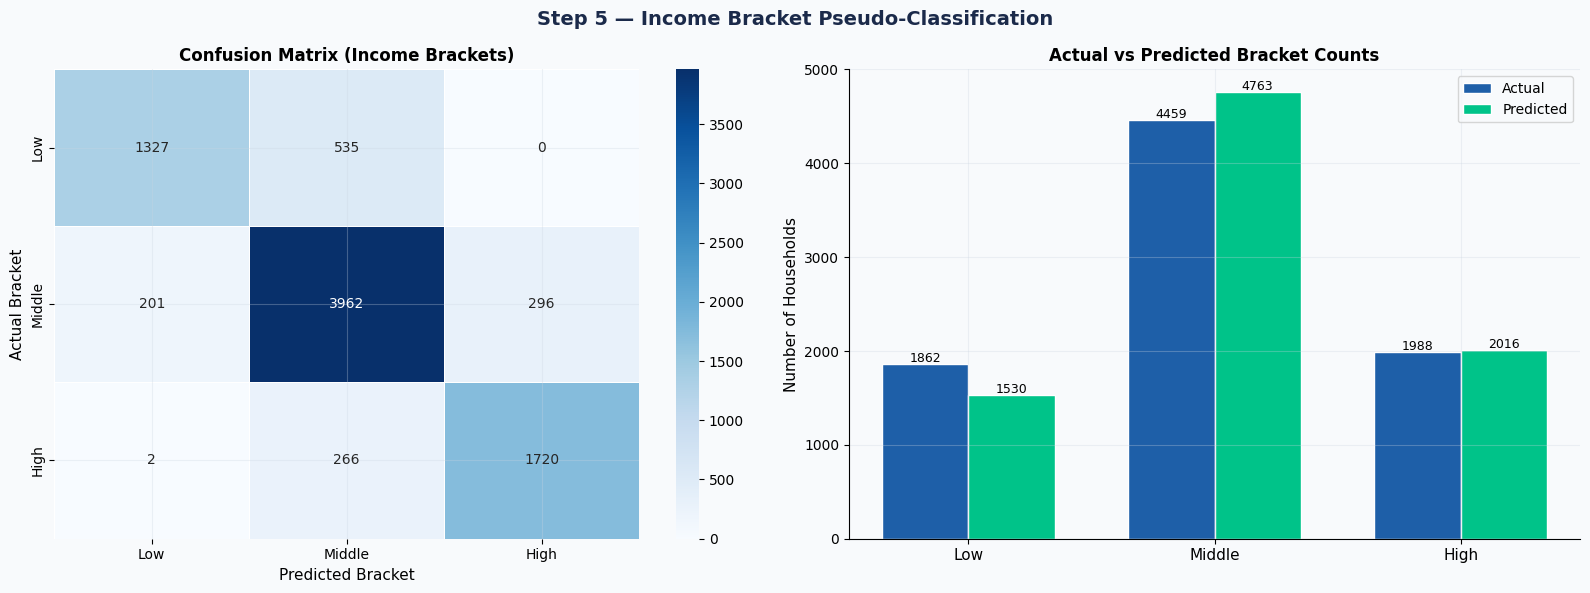

✅ Saved: income_bracket_classification.png
              precision    recall  f1-score   support

         Low       0.87      0.71      0.78      1862
      Middle       0.83      0.89      0.86      4459
        High       0.85      0.87      0.86      1988

    accuracy                           0.84      8309
   macro avg       0.85      0.82      0.83      8309
weighted avg       0.84      0.84      0.84      8309



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Both files downloaded!


In [64]:
# ============================================================
# FIXED CELL 11 — Residual Analysis
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

y_test_arr = np.array(y_test).ravel()
pred_arr   = np.array(pred_tuned).ravel()
residuals  = y_test_arr - pred_arr

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Residual Analysis — Random Forest (Tuned)',
             fontsize=16, fontweight='bold', color='#1B2A4A')

ax1 = axes[0]
ax1.scatter(pred_arr, residuals, alpha=0.3, s=12, color='#1E5FA8', edgecolors='none')
ax1.axhline(0, color='#E63946', linewidth=2, linestyle='--')
ax1.set_xlabel('Predicted Income (₱)', fontsize=11)
ax1.set_ylabel('Residual (Actual − Predicted) (₱)', fontsize=11)
ax1.set_title('Residuals vs. Predicted Values', fontsize=12, fontweight='bold')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₱{x/1e6:.1f}M'))
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₱{x/1e6:.1f}M'))
ax1.text(0.05, 0.92, f'Mean residual: ₱{residuals.mean():,.0f}',
         transform=ax1.transAxes, fontsize=10,
         bbox=dict(boxstyle='round', facecolor='#EAF1FB', edgecolor='#1E5FA8'))

ax2 = axes[1]
ax2.hist(residuals, bins=80, color='#00C389', edgecolor='white', linewidth=0.4, alpha=0.85)
ax2.axvline(residuals.mean(), color='#E63946', linewidth=2, linestyle='--',
            label=f'Mean: ₱{residuals.mean():,.0f}')
ax2.axvline(0, color='#1B2A4A', linewidth=1.5, linestyle='-', label='Zero line')
ax2.set_xlabel('Residual Value (₱)', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₱{x/1e6:.1f}M'))

ax3 = axes[2]
ax3.scatter(y_test_arr, residuals, alpha=0.3, s=12, color='#F4A300', edgecolors='none')
ax3.axhline(0, color='#E63946', linewidth=2, linestyle='--')
ax3.set_xlabel('Actual Income (₱)', fontsize=11)
ax3.set_ylabel('Residual (₱)', fontsize=11)
ax3.set_title('Residuals vs. Actual Values', fontsize=12, fontweight='bold')
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₱{x/1e6:.1f}M'))
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₱{x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: residual_analysis.png")


# ============================================================
# FIXED CELL 12B — Income Bracket Confusion Matrix
# ============================================================
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

bins   = [0, 100000, 300000, 1e12]
labels = ['Low\n(<₱100K)', 'Middle\n(₱100K–300K)', 'High\n(>₱300K)']

actual_brackets = pd.cut(y_test_arr, bins=bins, labels=labels)
pred_brackets   = pd.cut(pred_arr,   bins=bins, labels=labels)

mask           = actual_brackets.notna() & pred_brackets.notna()
actual_clean   = actual_brackets[mask]
pred_clean     = pred_brackets[mask]

cm = confusion_matrix(actual_clean, pred_clean, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Step 5 — Income Bracket Pseudo-Classification',
             fontsize=14, fontweight='bold', color='#1B2A4A')

ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Middle', 'High'],
            yticklabels=['Low', 'Middle', 'High'],
            ax=ax1, linewidths=0.5, linecolor='white')
ax1.set_title('Confusion Matrix (Income Brackets)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicted Bracket', fontsize=11)
ax1.set_ylabel('Actual Bracket', fontsize=11)

ax2 = axes[1]
actual_counts = pd.Series(actual_clean).value_counts().reindex(labels).fillna(0)
pred_counts   = pd.Series(pred_clean).value_counts().reindex(labels).fillna(0)
x = np.arange(len(labels))
w = 0.35
bars1 = ax2.bar(x - w/2, actual_counts.values, width=w, color='#1E5FA8', label='Actual', edgecolor='white')
bars2 = ax2.bar(x + w/2, pred_counts.values,   width=w, color='#00C389', label='Predicted', edgecolor='white')
ax2.set_xticks(x)
ax2.set_xticklabels(['Low', 'Middle', 'High'], fontsize=11)
ax2.set_ylabel('Number of Households', fontsize=11)
ax2.set_title('Actual vs Predicted Bracket Counts', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
for bars in [bars1, bars2]:
    for bar in bars:
        h = int(bar.get_height())
        if h > 0:
            ax2.text(bar.get_x() + bar.get_width()/2, h + 20,
                     str(h), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('income_bracket_classification.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: income_bracket_classification.png")
print(classification_report(actual_clean, pred_clean,
                             labels=labels,
                             target_names=['Low', 'Middle', 'High'],
                             zero_division=0))

# Download both
from google.colab import files
files.download('residual_analysis.png')
files.download('income_bracket_classification.png')
print("✅ Both files downloaded!")